mean:  120.70756512369792
stddev:  64.1500758911213


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 2, 2, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 2, 2, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,070,218 (19.34 MB)

 Trainable params: 5,070,218 (19.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 - 14s - 35ms/step - accuracy: 0.3738 - loss: 1.6610 - val_accuracy: 0.4413 - val_loss: 1.4504
Epoch 2/20
391/391 - 4s - 9ms/step - accuracy: 0.5150 - loss: 1.3291 - val_accuracy: 0.5180 - val_loss: 1.3315
Epoch 3/20
391/391 - 4s - 10ms/step - accuracy: 0.5718 - loss: 1.1961 - val_accuracy: 0.5687 - val_loss: 1.2157
Epoch 4/20
391/391 - 4s - 10ms/step - accuracy: 0.6122 - loss: 1.0945 - val_accuracy: 0.5982 - val_loss: 1.1502
Epoch 5/20
391/391 - 4s - 9ms/step - accuracy: 0.6356 - loss: 1.0204 - val_accuracy: 0.6053 - val_loss: 1.1159
Epoch 6/20
391/391 - 4s - 10ms/step - accuracy: 0.6655 - loss: 0.9513 - val_accuracy: 0.6412 - val_loss: 1.0459
Epoch 7/20
391/391 - 5s - 13ms/step - accuracy: 0.6841 - loss: 0.8934 - val_accuracy: 0.6446 - val_loss: 1.0133
Epoch 8/20
391/391 - 4s - 9ms/step - accuracy: 0.7007 - loss: 0.8448 - val_accuracy: 0.6392 - val_loss: 1.0581
Epoch 9/20
391/391 - 4s - 10ms/step - accuracy: 0.7197 - loss: 0.7972 - val_accuracy: 0.6570 - val_loss: 1

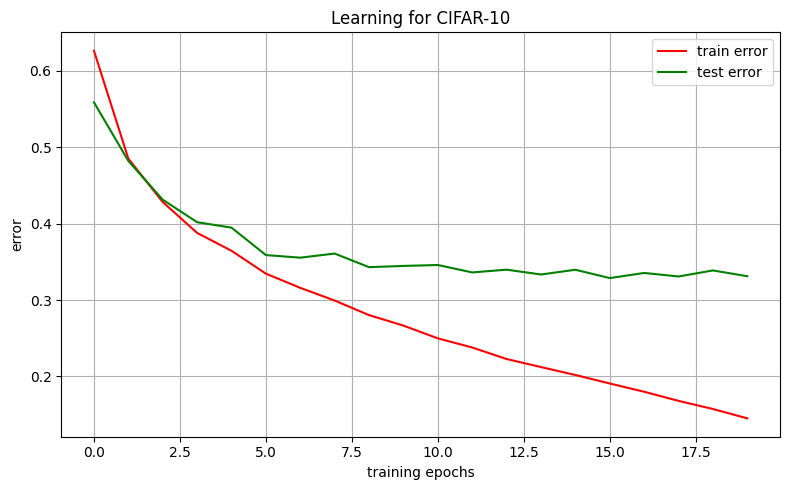

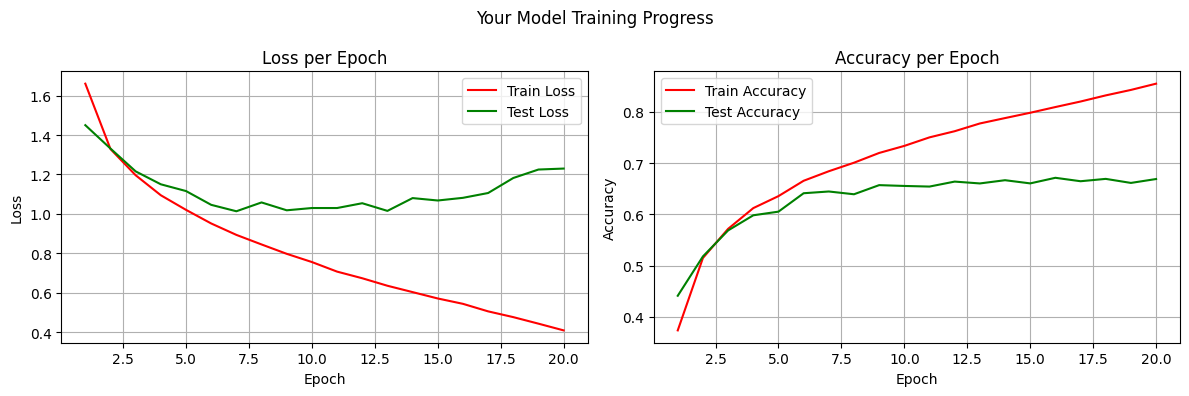

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step


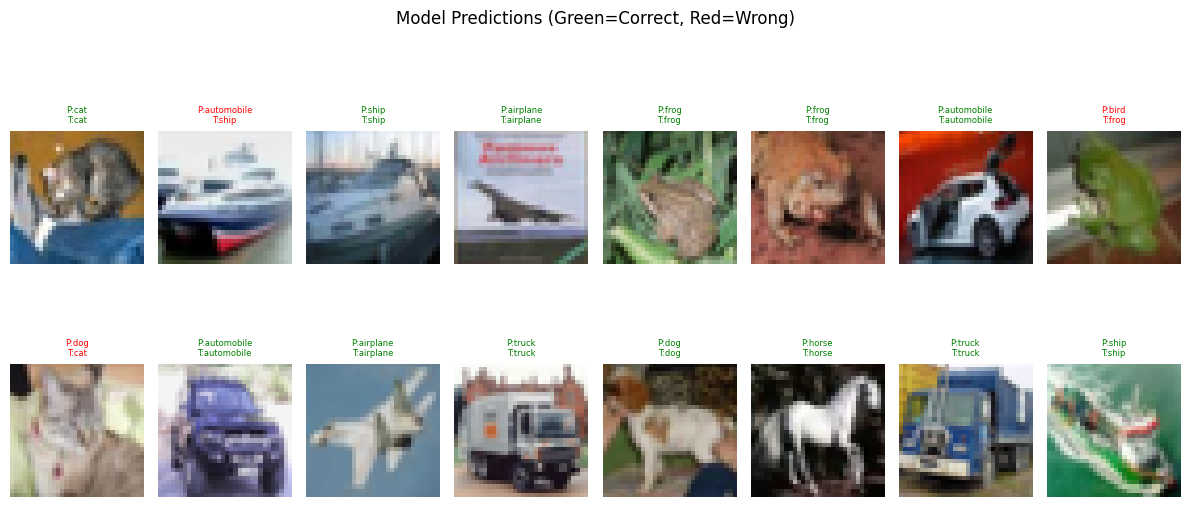

In [7]:
# -*- coding: utf-8 -*-
"""
Created on Wed Mar  4 20:40:09 2026

@author: THE MAD TITAN
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 20
BATCH_SIZE = 128

# Load dataset.
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images,
    test_labels) = cifar_dataset.load_data()

# Standardize dataset.
mean = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images = (test_images - mean) / stddev

print('mean: ', mean)
print('stddev: ', stddev)

# Change labels to one-hot.
train_labels = to_categorical(train_labels,
                              num_classes=10)
test_labels = to_categorical(test_labels,
                              num_classes=10)


# making AlexNet.
model = Sequential()
model.add(Conv2D(96, (11, 11), strides=(4,4),
                activation='relu', padding='same',
                input_shape=(32, 32, 3),
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

model.add(MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='same'))

model.add(Conv2D(256, (5, 5), strides=(1,1),
                activation='relu', padding='same',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

# adding maxpooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='same'))

model.add(Conv2D(384, (3, 3), strides=(1,1),
                activation='relu', padding='same',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))
model.add(Conv2D(384, (3, 3), strides=(1,1),
                activation='relu', padding='same',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))
model.add(Conv2D(256, (3, 3), strides=(1,1),
                activation='relu', padding='same',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

# adding maxpooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='same'))

model.add(GlobalAveragePooling2D())
model.add(Dense(1024, activation='relu',
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros'))
model.add(Dense(1024, activation='relu',
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros'))
model.add(Dense(10, activation='softmax',
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics =['accuracy'])
model.summary()
history = model.fit(
    train_images, train_labels, validation_data =
    (test_images, test_labels), epochs=EPOCHS,
    batch_size=BATCH_SIZE, verbose=2, shuffle=True)


import matplotlib.pyplot as plt

# ============================================================
# 1. TRAINING HISTORY - Train Error vs Test Error (Slide 6)
# ============================================================
train_error = [1 - acc for acc in history.history['accuracy']]
test_error  = [1 - acc for acc in history.history['val_accuracy']]

plt.figure(figsize=(8, 5))
plt.plot(train_error, color='red',  label='train error')
plt.plot(test_error,  color='green', label='test error')
plt.xlabel('training epochs')
plt.ylabel('error')
plt.title('Learning for CIFAR-10')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 8. LIVE TRAINING LOSS & ACCURACY PER EPOCH (Bonus)
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'],     label='Train Loss', color='red')
plt.plot(epochs_range, history.history['val_loss'], label='Test Loss',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='red')
plt.plot(epochs_range, history.history['val_accuracy'], label='Test Accuracy',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.suptitle('Your Model Training Progress')
plt.tight_layout()
plt.show()

# ============================================================
# 9. SAMPLE PREDICTIONS - What is the model seeing? (Bonus)
# ============================================================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Get raw test images (before standardization) for display
cifar_dataset = tf.keras.datasets.cifar10
(_, _), (raw_test_images, raw_test_labels) = cifar_dataset.load_data()

predictions = model.predict(test_images[:16])
pred_classes = np.argmax(predictions, axis=1)
true_classes = raw_test_labels[:16].flatten()

plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(raw_test_images[i])
    color = 'green' if pred_classes[i] == true_classes[i] else 'red'
    plt.title(f'P:{class_names[pred_classes[i]]}\nT:{class_names[true_classes[i]]}',
              fontsize=6, color=color)
    plt.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()